In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from typing import Callable, Optional
import sys
import os

# This (hopefully) sets the root directory for anyone using the repo
cwd = os.getcwd()  # poison-perf/poisoning/
root = os.path.dirname(cwd)  # poison-perf/
sys.path.append(root)

from utils.algorithms import RGD, RGD_audit, PerfGD
from utils.experiment_setup import setup_1d_non_linear_experiment, setup_binary_classification, setup_non_convex_1d, setup_2d_non_linear_experiment
# from poisoning.oracle import oracle_poison_function, RGD_update_estimator, PerfGD_update_estimator, classification_sampling_estimator, gaussian_sampling_estimator
from poisoning.black_box_poison import black_box_poison_naive, black_box_poison_orthogonal, black_box_poison_cluster
from utils.plotting import plot_results_1d, plot_results_2d

# Nonlinear Mean

In [2]:
a0 = 1.0
a1 = 1.0

proj_theta = lambda theta: torch.clamp(theta, min=-1.0, max=1.0)
mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat, info = setup_1d_non_linear_experiment(a0=a0, a1=a1, perfGD=True)

### Visualize Effect of Black Box Mean Shift on Samples


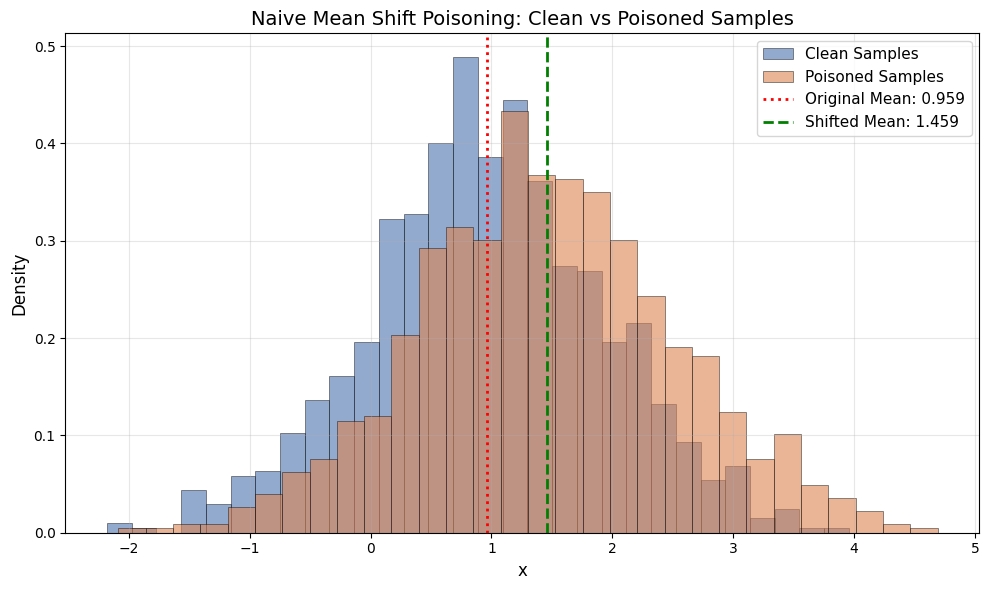

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Naive Mean Shift Poisoning: Clean vs Poisoned Samples'}, xlabel='x', ylabel='Density'>)

In [3]:
# Visualize poisoning effect on samples (1D Nonlinear Mean Shift)
from utils.plotting import plot_clean_vs_poisoned_samples_1d

# Set up parameters
black_box_poison_function = black_box_poison_naive  # Changed to naive mean shift
epsilon = 0.5
delta = 1.0
n = 1000

# Get initial clean samples (no RGD, just one sample from D_theta)
z_clean = D_theta(theta_0, n)

# Apply poisoning once
z_poisoned = black_box_poison_function(
    z_clean, 
    theta_0, 
    eta=0.05,  # Not used by naive, but required
    epsilon=epsilon,
    delta=delta
)

# Visualize the comparison
plot_clean_vs_poisoned_samples_1d(z_clean, z_poisoned, title_prefix="Naive Mean Shift Poisoning: ")

## RGD + Naive Mean Shift

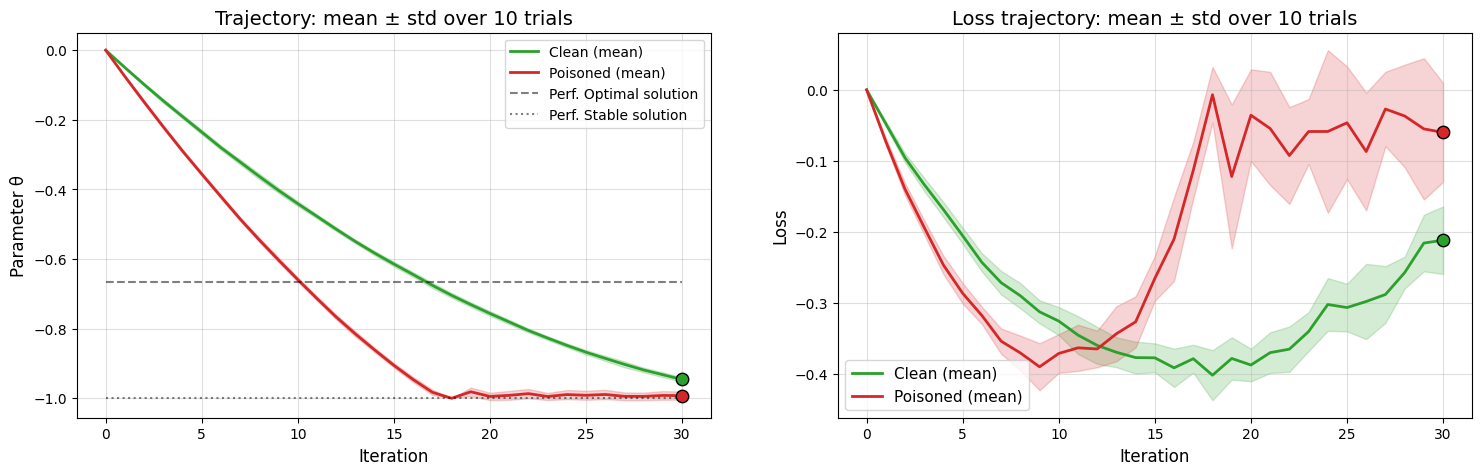

In [4]:
black_box_poison_function = black_box_poison_naive

n_trials = 10

n = 500
eta = 0.05
max_iter = 30

epsilon = 0.5
delta = 1.0

def run_trial():
    _, all_theta_clean, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                proj_theta=proj_theta,
                normalize_grad=False,
                return_losses=True
    )

    _, all_theta_poisoned, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                proj_theta=proj_theta,
                normalize_grad=False,
                return_losses=True,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
            )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_1d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

ax1.hlines(info['theta_optimal'], xmin=0, xmax=30, color='black', linestyle='--', label='Perf. Optimal solution', alpha=0.5)
ax1.hlines(info['theta_stable'], xmin=0, xmax=30, color='black', linestyle=':', label='Perf. Stable solution', alpha=0.5)
ax1.legend()

plt.show()

### Plot loss and theta gap as a function of delta

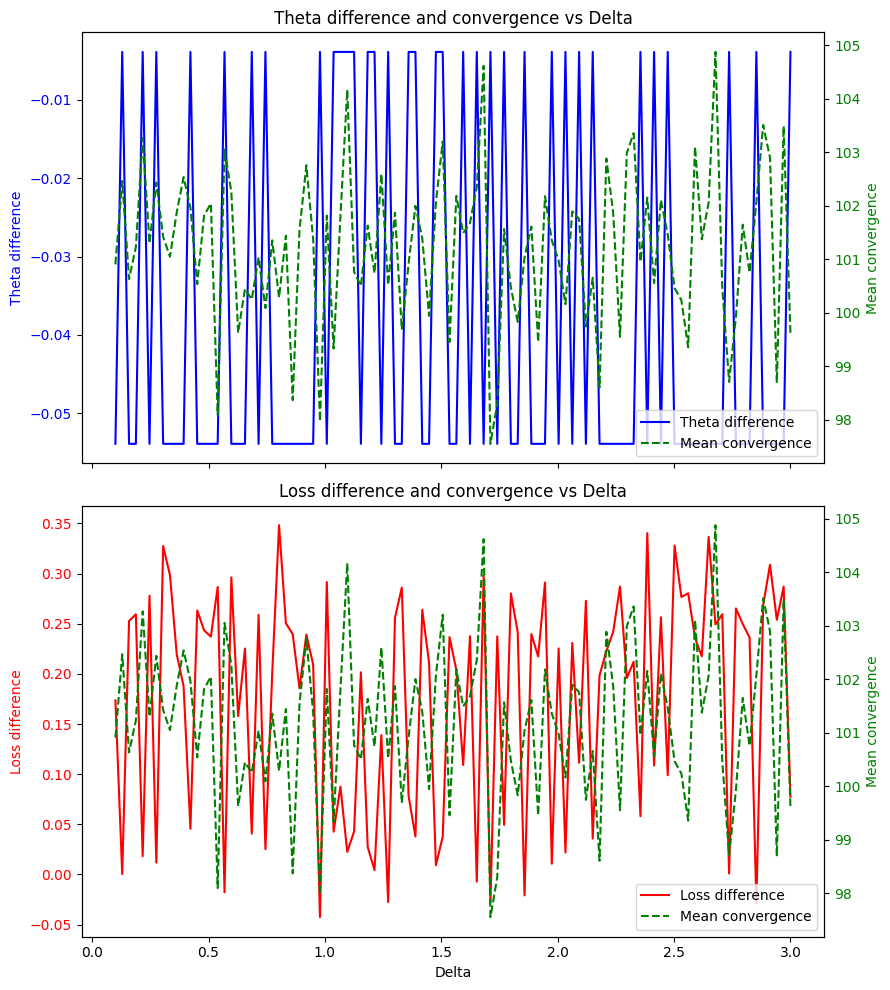

In [5]:
delta_vals = np.linspace(0.1, 3.0, 100)
black_box_poison_function = black_box_poison_naive
epsilon = 0.5

theta_clean, _, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True
    )

theta_clean = theta_clean.item()
loss_clean = all_losses_clean[-1]

losses_poisoned, theta_poisoned, mean_convergence = [], [], []
for delta in delta_vals:
    _theta_poisoned, _, all_losses_poisoned, convergence_metrics = RGD_audit(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                epsilon=epsilon,
                delta=delta,
    )

    losses_poisoned.append(all_losses_poisoned[-1])
    theta_poisoned.append(_theta_poisoned.item())
    mean_convergence.append(np.mean(convergence_metrics))

losses_poisoned = np.array(losses_poisoned)
theta_poisoned = np.array(theta_poisoned)
mean_convergence = np.array(mean_convergence)

# Create two subplots: top = theta gap, bottom = loss gap
fig, (ax_theta, ax_loss) = plt.subplots(2, 1, figsize=(9, 10), sharex=True)

# Theta subplot (left axis: theta gap, right axis: convergence)
ln_theta = ax_theta.plot(delta_vals, theta_poisoned - theta_clean, color='blue', label='Theta difference')
ax_theta.set_ylabel('Theta difference', color='blue')
ax_theta.tick_params(axis='y', labelcolor='blue')
ax_theta.set_title('Theta difference and convergence vs Delta')
ax_theta_right = ax_theta.twinx()
ln_conv_theta = ax_theta_right.plot(delta_vals, mean_convergence, color='green', linestyle='--', label='Mean convergence')
ax_theta_right.set_ylabel('Mean convergence', color='green')
ax_theta_right.tick_params(axis='y', labelcolor='green')
# Combined legend for theta subplot
lines = ln_theta + ln_conv_theta
labels = [l.get_label() for l in lines]
ax_theta.legend(lines, labels, loc='lower right')

# Loss subplot (left axis: loss gap, right axis: convergence)
ln_loss = ax_loss.plot(delta_vals, losses_poisoned - loss_clean, color='red', label='Loss difference')
ax_loss.set_xlabel('Delta')
ax_loss.set_ylabel('Loss difference', color='red')
ax_loss.tick_params(axis='y', labelcolor='red')
ax_loss.set_title('Loss difference and convergence vs Delta')
ax_loss_right = ax_loss.twinx()
ln_conv_loss = ax_loss_right.plot(delta_vals, mean_convergence, color='green', linestyle='--', label='Mean convergence')
ax_loss_right.set_ylabel('Mean convergence', color='green')
ax_loss_right.tick_params(axis='y', labelcolor='green')
# Combined legend for loss subplot
lines = ln_loss + ln_conv_loss
labels = [l.get_label() for l in lines]
ax_loss.legend(lines, labels, loc='lower right')

plt.tight_layout()
plt.show()

### Save Results

In [6]:
import pickle
pickle.dump({
    "delta_vals": delta_vals, 
    "theta_diff": theta_poisoned - theta_clean, 
    "loss_diff": losses_poisoned - loss_clean
}, open("black_box_poison_rgd_delta_sweep.pkl", "wb"))

## PerfGD + Naive Mean Shift

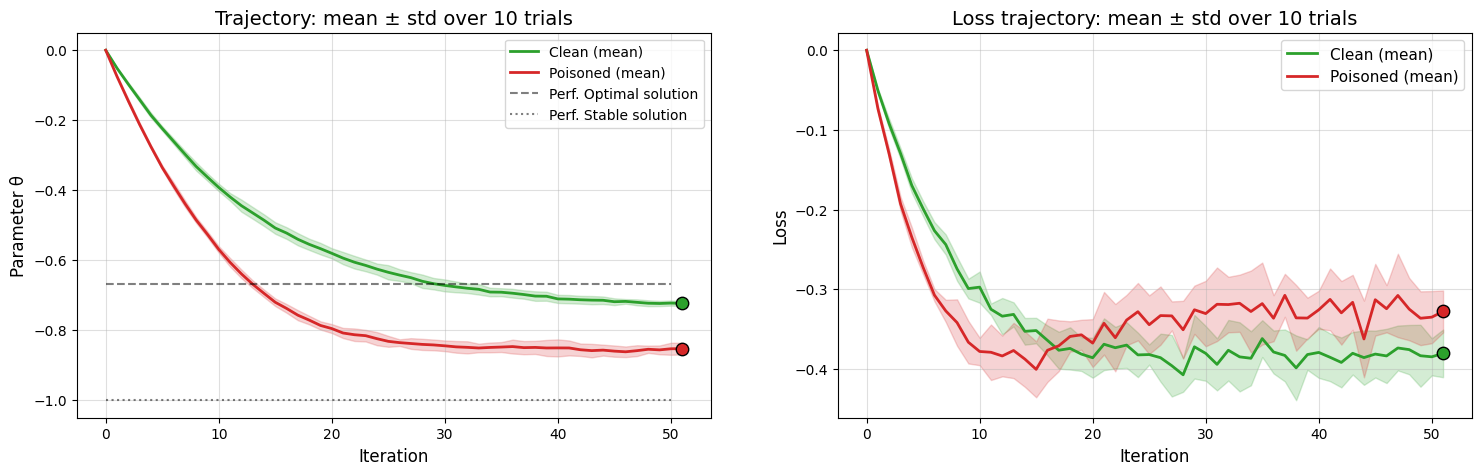

In [7]:
black_box_poison_function = black_box_poison_naive

n_trials = 10

n = 500
eta = 0.05
max_iter = 50

epsilon = 0.5
delta = 1.0

def run_trial():
    _, all_theta_clean, all_losses_clean = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True  
    )

    _, all_theta_poisoned, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
    )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_1d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

ax1.hlines(info['theta_optimal'], xmin=0, xmax=50, color='black', linestyle='--', label='Perf. Optimal solution', alpha=0.5)
ax1.hlines(info['theta_stable'], xmin=0, xmax=50, color='black', linestyle=':', label='Perf. Stable solution', alpha=0.5)
ax1.legend()

plt.show()

### PerfGD: Plot loss and theta gap as a function of delta

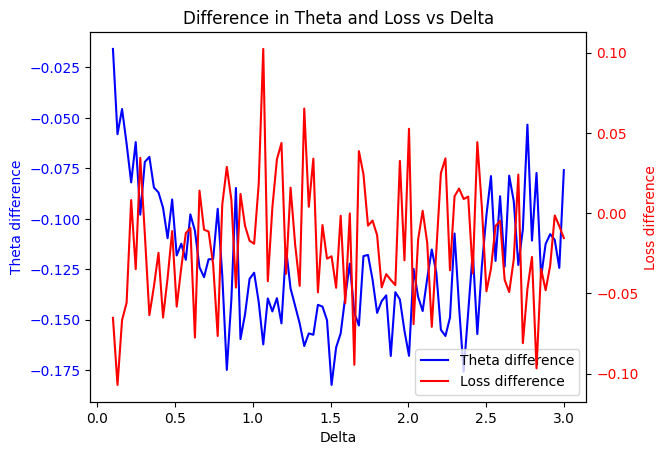

In [8]:
delta_vals = np.linspace(0.1, 3.0, 100)
black_box_poison_function = black_box_poison_naive
epsilon = 0.5

theta_clean, _, all_losses_clean = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True  
    )

theta_clean = theta_clean.item()
loss_clean = all_losses_clean[-1]

losses_poisoned, theta_poisoned = [], []
for delta in delta_vals:
    _theta_poisoned, _, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
    )

    losses_poisoned.append(all_losses_poisoned[-1])
    theta_poisoned.append(_theta_poisoned.item())

losses_poisoned = np.array(losses_poisoned)
theta_poisoned = np.array(theta_poisoned)

fig, ax_left = plt.subplots()
# Left axis: theta difference
ln1 = ax_left.plot(delta_vals, theta_poisoned - theta_clean, color='blue', label='Theta difference')
ax_left.set_xlabel('Delta')
ax_left.set_ylabel('Theta difference', 
                   color='blue')
ax_left.tick_params(axis='y', labelcolor='blue')

# Right axis: loss difference
ax_right = ax_left.twinx()
ln2 = ax_right.plot(delta_vals, losses_poisoned - loss_clean, color='red', label='Loss difference')
ax_right.set_ylabel('Loss difference', color='red')
ax_right.tick_params(axis='y', labelcolor='red')

# Combined legend
lines = ln1 + ln2
labels = [l.get_label() for l in lines]
ax_left.legend(lines, labels, loc='lower right')

ax_left.set_title('Difference in Theta and Loss vs Delta')
plt.show()

In [9]:
import pickle
pickle.dump({
    "delta_vals": delta_vals, 
    "theta_diff": theta_poisoned - theta_clean, 
    "loss_diff": losses_poisoned - loss_clean
}, open("black_box_poison_perfgd_delta_sweep.pkl", "wb"))


# Binary Classification

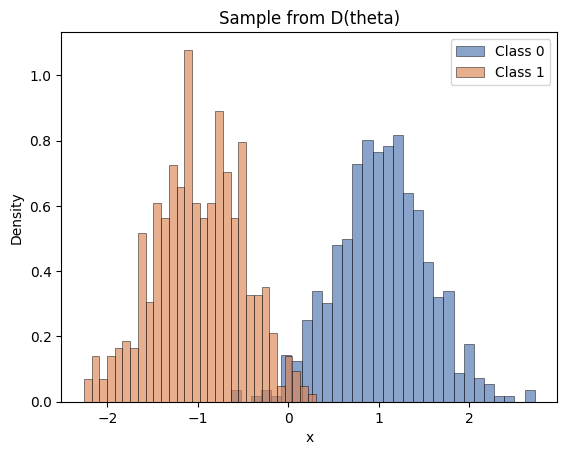

In [10]:
mu_f, mu_0, sigma_0, sigma_1, D_theta, loss, theta_0, grad2_est, f_hat = setup_binary_classification(perfGD=True)

x, y = D_theta(n=1000, theta=theta_0)

# prettier colors and styled histograms
colors = ['#4C72B0', '#DD8452']  # muted blue and warm orange

x0 = x[(y == 0).bool()].numpy()
x1 = x[(y == 1).bool()].numpy()

plt.hist(x0, bins=30, density=True, alpha=0.65, color=colors[0],
         edgecolor='k', linewidth=0.5, label='Class 0')
plt.hist(x1, bins=30, density=True, alpha=0.65, color=colors[1],
         edgecolor='k', linewidth=0.5, label='Class 1')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Sample from D(theta)')
plt.legend(frameon=True)
plt.show()

### Visualize Effect of Black Box Poisoning on Clusters

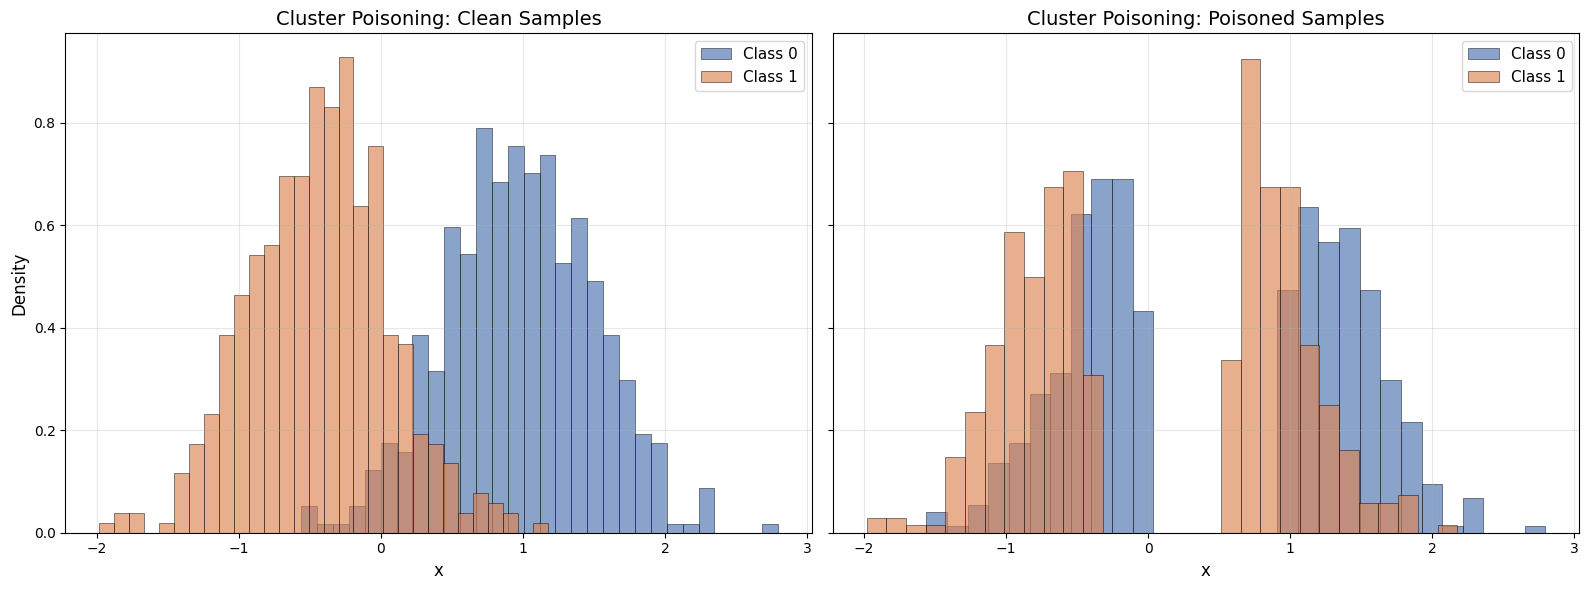

(<Figure size 1600x600 with 2 Axes>,
 (<Axes: title={'center': 'Cluster Poisoning: Clean Samples'}, xlabel='x', ylabel='Density'>,
  <Axes: title={'center': 'Cluster Poisoning: Poisoned Samples'}, xlabel='x'>))

In [11]:
# Visualize poisoning effect on samples
from utils.plotting import plot_clean_vs_poisoned_samples

# Set up parameters
black_box_poison_function = black_box_poison_cluster
epsilon = 0.5
delta = 1.0
n = 1000
eta = 0.05
max_iter = 30
proj_theta = lambda theta: theta  # or your projection function

# Run RGD with return_samples=True to get clean and poisoned samples
_, _, z_clean, z_poisoned = RGD(
    D_theta=D_theta,
    loss=loss,
    theta_0=theta_0.clone(),
    n=n,
    eta=eta,
    max_iter=max_iter,
    proj_theta=proj_theta,
    poison_function=black_box_poison_function,
    normalize_grad=False,
    return_samples=True,  # This returns z_clean and z_poisoned
    epsilon=epsilon,
    delta=delta
)

# Visualize the comparison
plot_clean_vs_poisoned_samples(z_clean, z_poisoned, title_prefix="Cluster Poisoning: ")

## RGD + Cluster Shift

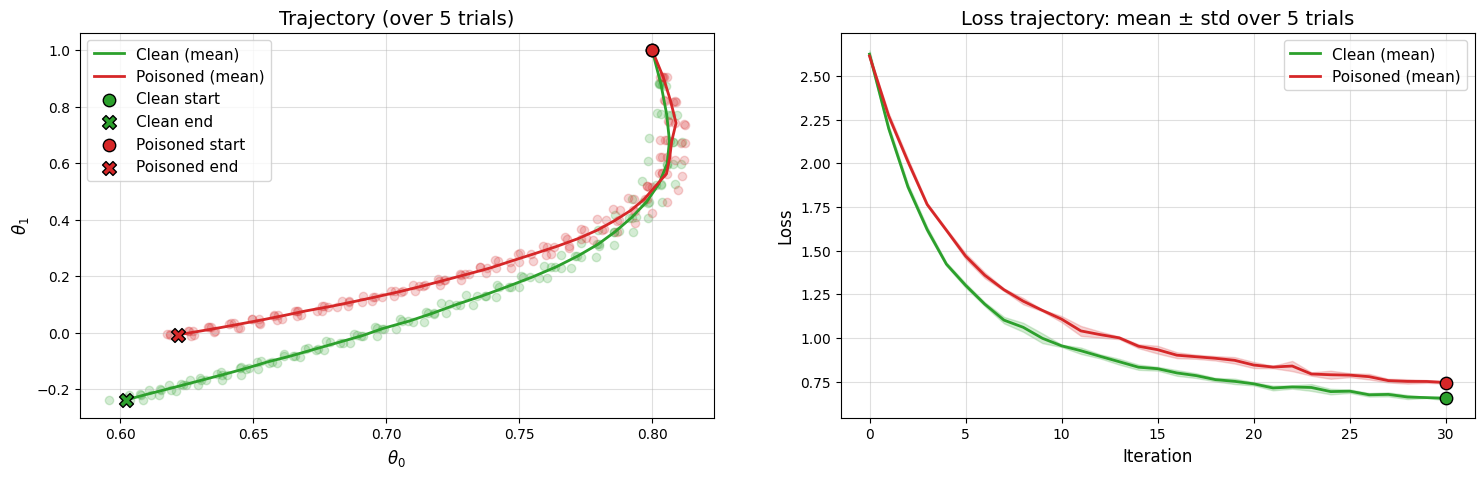

In [12]:
black_box_poison_function = black_box_poison_cluster

n_trials = 5

n = 500
eta = 0.05
max_iter = 30

epsilon = 0.5
delta = 1

theta_0 = torch.tensor([0.8,1.0])

def run_trial():
    _, all_theta_clean, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True
    )

    _, all_theta_poisoned, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
    )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_2d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

plt.show()

### Plot theta and loss gap vs. delta

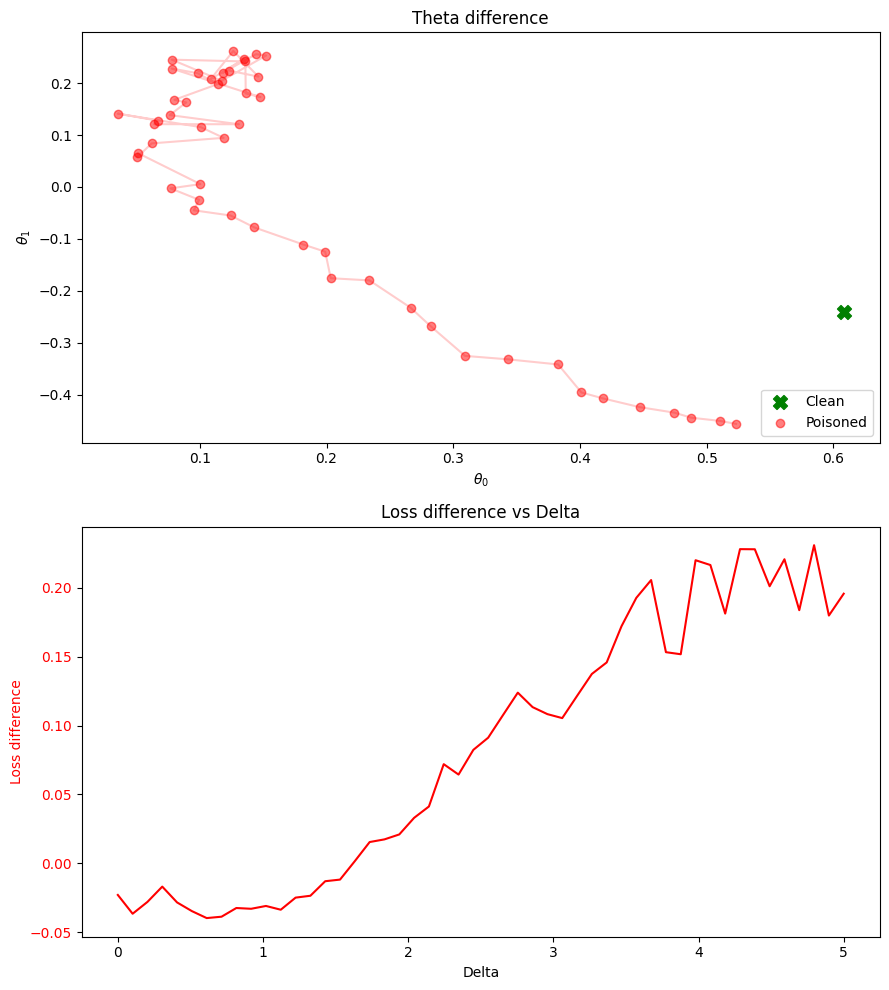

In [13]:
black_box_poison_function = black_box_poison_cluster
delta_vals = np.linspace(0.0, 5, 50)
epsilon = 0.5

theta_clean, _, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True
    )

theta_clean = theta_clean
loss_clean = all_losses_clean[-1]

losses_poisoned, theta_poisoned = [], []
for delta in delta_vals:
    _theta_poisoned, _, all_losses_poisoned , _ = RGD_audit(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
                last_step_only=False
    )

    losses_poisoned.append(all_losses_poisoned[-1])
    theta_poisoned.append(_theta_poisoned)

losses_poisoned = np.array(losses_poisoned)
theta_poisoned = np.array(theta_poisoned)

# Create two subplots: top = theta gap, bottom = loss gap
fig, (ax_theta, ax_loss) = plt.subplots(2, 1, figsize=(9, 10), sharex=False)

ax_theta.scatter(theta_clean[0], theta_clean[1], color='green', label='Clean', marker='X', s=100, zorder=5)
ax_theta.scatter(theta_poisoned[:,0], theta_poisoned[:,1], color='red', label='Poisoned', marker='o', alpha=0.5)
ax_theta.plot(theta_poisoned[:,0], theta_poisoned[:,1], color='red', alpha=0.2)
ax_theta.set_ylabel(r'$\theta_1$', color='k')
ax_theta.set_xlabel(r'$\theta_0$', color='k')
ax_theta.set_title('Theta difference')

# Combined legend for theta subplot
ax_theta.legend(loc='lower right')

# Loss subplot (left axis: loss gap, right axis: convergence)
ln_loss = ax_loss.plot(delta_vals, losses_poisoned - loss_clean, color='red', label='Loss difference')
ax_loss.set_xlabel('Delta')
ax_loss.set_ylabel('Loss difference', color='red')
ax_loss.tick_params(axis='y', labelcolor='red')
ax_loss.set_title('Loss difference vs Delta')

plt.tight_layout()
plt.show()

In [14]:
import pickle

pickle.dump({"delta_vals": delta_vals, "theta_diff": np.linalg.norm(theta_poisoned - theta_clean.numpy(), axis=-1), "loss_diff": losses_poisoned - loss_clean}, open("black_box_poison_cluster_rgd_delta_sweep.pkl", "wb"))

# 2D Example

In [15]:
mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat, info = setup_2d_non_linear_experiment(perfGD=True)
proj_theta = lambda theta: torch.clamp(theta, min=-1.0, max=1.0)

## RGD + Orthogonal Mean Shift

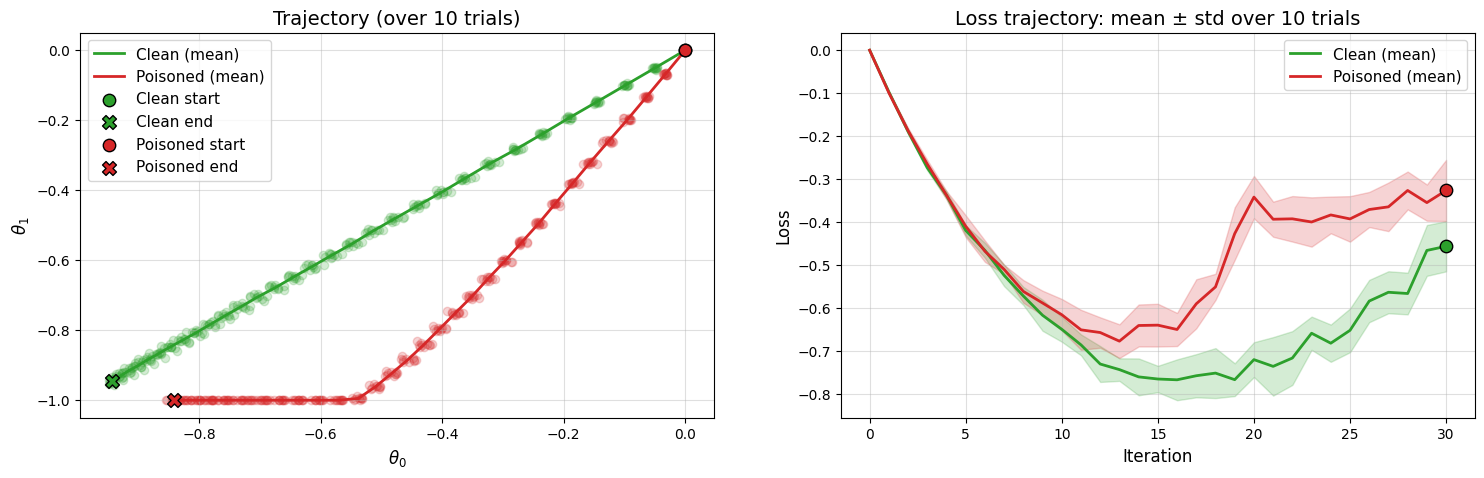

In [16]:
black_box_poison_function = black_box_poison_orthogonal

n_trials = 10

n = 500
eta = 0.05
max_iter = 30

epsilon = 0.5
delta = 1.0

def run_trial():
    _, all_theta_clean, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True
    )

    _, all_theta_poisoned, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
            )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_2d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

plt.show()

### Plot Loss and Theta Gap Vs. Delta 

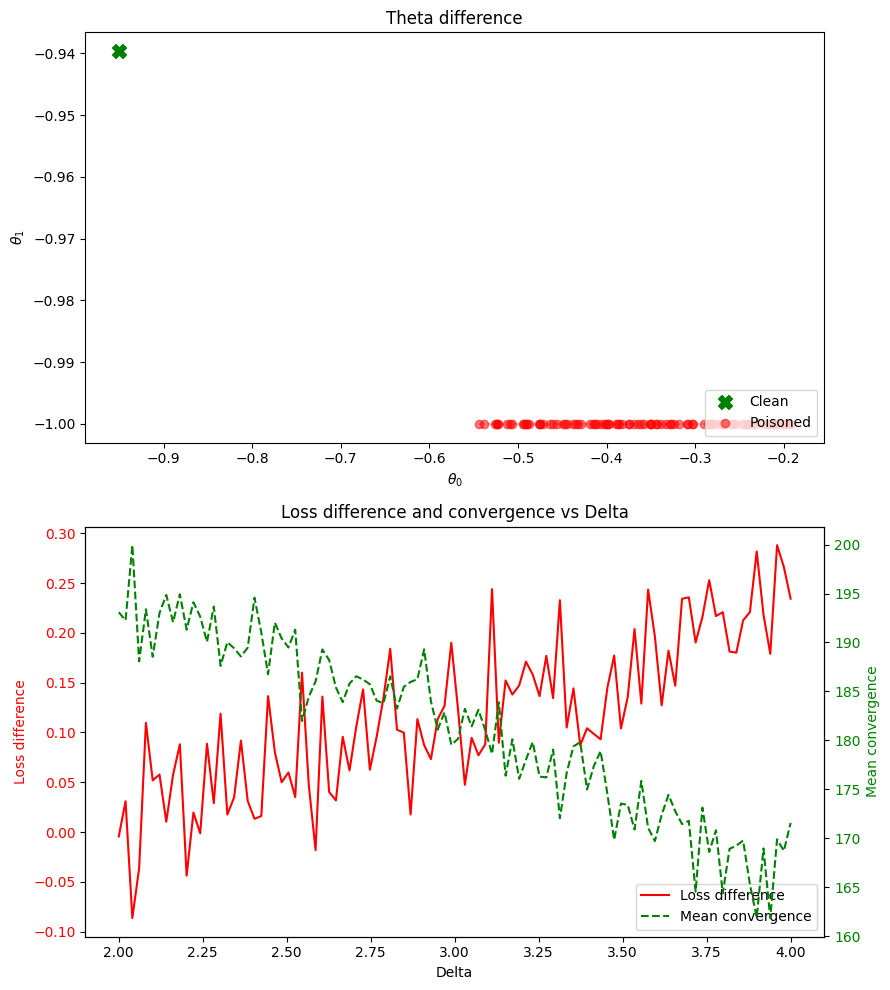

In [17]:
black_box_poison_function = black_box_poison_orthogonal

delta_vals = np.linspace(2.0, 4, 100)
epsilon = 0.5

theta_clean, _, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True
    )

theta_clean = theta_clean
loss_clean = all_losses_clean[-1]

losses_poisoned, theta_poisoned, mean_convergence = [], [], []
for delta in delta_vals:
    _theta_poisoned, _, all_losses_poisoned, cvg_metric = RGD_audit(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
                last_step_only=False
    )

    losses_poisoned.append(all_losses_poisoned[-1])
    theta_poisoned.append(_theta_poisoned)
    mean_convergence.append(np.mean(cvg_metric))

losses_poisoned = np.array(losses_poisoned)
theta_poisoned = np.array(theta_poisoned)
mean_convergence = np.array(mean_convergence)

# Create two subplots: top = theta gap, bottom = loss gap
fig, (ax_theta, ax_loss) = plt.subplots(2, 1, figsize=(9, 10), sharex=False)

ax_theta.scatter(theta_clean[0], theta_clean[1], color='green', label='Clean', marker='X', s=100, zorder=5)
ax_theta.scatter(theta_poisoned[:,0], theta_poisoned[:,1], color='red', label='Poisoned', marker='o', alpha=0.5)
ax_theta.plot(theta_poisoned[:,0], theta_poisoned[:,1], color='red', alpha=0.2)
ax_theta.set_ylabel(r'$\theta_1$', color='k')
ax_theta.set_xlabel(r'$\theta_0$', color='k')
ax_theta.set_title('Theta difference')

# Combined legend for theta subplot
ax_theta.legend(loc='lower right')

ln_loss = ax_loss.plot(delta_vals, losses_poisoned - loss_clean, color='red', label='Loss difference')
ax_loss.set_xlabel('Delta')
ax_loss.set_ylabel('Loss difference', color='red')
ax_loss.tick_params(axis='y', labelcolor='red')
ax_loss.set_title('Loss difference and convergence vs Delta')
ax_loss_right = ax_loss.twinx()
ln_conv_loss = ax_loss_right.plot(delta_vals, mean_convergence, color='green', linestyle='--', label='Mean convergence')
ax_loss_right.set_ylabel('Mean convergence', color='green')
ax_loss_right.tick_params(axis='y', labelcolor='green')
# Combined legend for loss subplot
lines = ln_loss + ln_conv_loss
labels = [l.get_label() for l in lines]
ax_loss.legend(lines, labels, loc='lower right')

plt.tight_layout()
plt.show()

## PerfGD + Orthogonal Mean Shift

### Some kind of comparison for naive vs orthogonal?